# TODO:

## None

In [23]:
import numpy as np
import random
import matplotlib.pyplot as plt
from   matplotlib.animation import FuncAnimation
from   matplotlib import animation, colors

class DLA:
    def __init__(self, grid_size, stickiness, max_particles):
        """
        Initialization function:
            Common python convention is to use __init__ for initialization of class attributes.
            This function sets up the grid, initializes the cluster with a seed particle, and prepares parameters for the simulation.
        """
        # Initialize parameters
        self.grid_size      = grid_size                         # Length and width of the square grid
        self.center         = grid_size // 2                    # Center of the grid
        self.max_steps      = grid_size * 10                    # Maximum steps a particle can take before being considered "lost" (to prevent infinite wandering)
        self.stickiness     = stickiness                        # Probability of sticking when adjacent
        self.max_particles  = max_particles                     # Total number of particles to add to the cluster 

        # Initialize grid
        self.grid           = np.zeros((grid_size, grid_size))  # Create the square grid (matrix) 
        self.grid[self.center, self.center] = 1                 # Used floor division to ensure integer index. Put seed in the center of grid
        
        # Initialize cluster
        self.cluster_particles  = [(self.center, self.center)]  # Creates a tuple list to store the coords of particles in the cluster
        self.cluster_radius = 1                                 # Initial radius of the cluster (distance from center to farthest particle)
        self.kill_radius    = (self.cluster_radius * 1.25) + 10 # Prevent infinite walking (particles wandering forever)

    def new_particle(self):
        """
        Introduce a new particle on a circle around the cluster
        Use random angle to place the particle on the circumference of a circle 
        Use a radius that is larger than the current cluster radius
        """
        theta   = random.uniform(0, 2*np.pi)                    # Random angle
        r       = min(self.cluster_radius + 5, self.center - 2) # Starting position is outside the cluster, so the particle can diffuse

        x = int(self.center + r * np.cos(theta))                # The int() function forces the resulting vector to be an integer value
        y = int(self.center + r * np.sin(theta))                # Since we are using computers and walking particles on a lattice, we need ints
        
        return x, y

    def step(self, x, y):
        """
        I have learned that python has a great built-in "random" library
        This simple function simply takes the current pos, and randomly steps it
        """
        direction = random.choice([(1,0),(-1,0),(0,1),(0,-1),(1,1),(1,-1),(-1,1),(-1,-1)])
        return x + direction[0], y + direction[1]
    
    def walk(self):
        """
        Was initially apart of the simulation method, but I broke it into a seperate method
        This function simulates the random walk of a single particle until it either sticks to the cluster or wanders too far away.
        """
        x, y = self.new_particle()                              # Start a new particle
        steps = 0                                               # Step counter for ending loop (prevent infinite loops)

        while steps < self.max_steps:
            x, y =self.step(x, y)                               # Take a random step
            steps = steps + 1                                   # Increment step counter
            """ 
            If particle wonders too far away from cluster: (e.g. if it tries to leave the grid)
                Simulate it "leaving" and another particle "entering" 
                by breaking the loop and starting a new one with a new particle.
            """
            r = np.sqrt((x - self.center)**2 + (y - self.center)**2)
            if (r > self.kill_radius):                          # The spawn distance was radius*2... don't let it leave the grid, prevent edge cases
                x, y = self.new_particle()                      # Respawn a new particle, the code will automatically stop tracking the old one and start tracking the new one
                steps = 0                                       # Reset step counter for the new particle

            # Determine if the particle is adjacent to the cluster and should stick
            neighbors = self.neighbor_counter(x, y)                # Check if the particle is adjacent to the cluster
            if neighbors > 0:
                p_stick = 1 - (1 - self.stickiness)**neighbors  # Calculate the probability of sticking based on the number of adjacent cluster particles
                if random.random() < p_stick:                   # This is where stickiness/probability matters. btw, random.random() generates a float between 0 and 1
                    return x, y                                 # The particle stuck: end here

        # Else, return None, indicating the particle wandered without sticking
        return None

    def neighbor_counter(self, x, y):
        """
        Short function that checks surrounding positions for cluster particles.
        Might modify later to check for multiple contact points
        """
        surrounding_pts = [(1,0),(1,-1),(0,-1),(-1,-1),(-1,0),(-1,1),(0,1),(1,1)]   # Steps needed to get from curr_pos to all surrounding_pts
        neighbors = 0                                   # Counter to track how many cluster particles are adjacent (for potential future use)
        for dx, dy in surrounding_pts:                  # Quick loop through all surrounding points
            nx, ny = x + dx, y + dy
            if 0 <= nx < self.grid_size and 0 <= ny < self.grid_size:
                if self.grid[nx, ny] > 0:               # Check if any surrounding point is part of the cluster
                    neighbors = neighbors + 1
        return neighbors

    def update_cluster_radius(self, x, y):
        r = np.sqrt((x - self.center)**2 + (y - self.center)**2)    # Simple distance formula to find new rad
        if r > self.cluster_radius:                                 # Check if radius needs updated
            self.cluster_radius = r                                 # Update as needed   
            self.kill_radius    = (self.cluster_radius * 1.25) + 10 # Prevent infinite walking (particles wandering forever)

    def simulate(self):
        """
        Main loop for simulating the DLA process
        """
        particles_added = 1                             # From the seed
        
        while particles_added < self.max_particles:
            result = self.walk()                        # Simulate the random walk for a single particle
            
            if result is not None:
                # The particle stuck:
                x, y = result                           # Unpack the coordinates of the stuck particle
                self.grid[x, y] = particles_added       # Update grid 
                self.cluster_particles.append((x, y))   # Add particle to cluster list
                self.update_cluster_radius(x, y)        # Update cluster radius if needed
                particles_added += 1                    # Increment the count of particles in the cluster
            
            #if particles_added % 1000 == 0:
        self.plot()                             # Plot the cluster after each new particle sticks (can be commented out for faster simulation)
        self.analyze_fractal()

    def plot(self):
        # https://matplotlib.org/stable/api/figure_api.html
        plt.figure(figsize=(8,8))                       # This simply adjusts the size of the plot (width, height) in in.
       
        # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
        plt.imshow(self.grid, cmap='magma', origin='lower')   # This is the main plotting. It takes the value of each cell in the grid and maps it to a color (logrithmicly: hince the +1)
       
        # https://matplotlib.org/stable/api/colorbar_api.html
        plt.colorbar(label='Particle Deposition Order (Growth Time Step)')  # This just adds the colorbar for clarity, showing the age of particles in the cluster (log scale)

        plt.title('Diffusion Limited Aggregation Cluster Growth')
        
        # https://matplotlib.org/stable/api/axis_api.html
        plt.axis('off')                                 # Turns looks better

    def analyze_fractal(self, radial_bins=50, box_sizes=None):
        """
        PLOTS FOR
        1. Fractal dimension as a function of radius
        2. Capacity (box-counting) dimension vs box size S

        Parameters:
            radial_bins: Number of bins for radial fractal analysis
            box_sizes: List of box sizes for box-counting; if None, will use powers of 2
        """
        # ----------------------------
        # Radial fractal dimension
        # ----------------------------
        # Compute distance of each particle from the center
        positions = np.array(self.cluster_particles)
        dx = positions[:,0] - self.center
        dy = positions[:,1] - self.center
        radii = np.sqrt(dx**2 + dy**2)
        max_r = np.max(radii)

        # Radial bins
        bin_edges = np.linspace(0, max_r, radial_bins + 1)
        M_r = np.zeros(radial_bins)

        for i in range(radial_bins):
            r_min, r_max = bin_edges[i], bin_edges[i+1]
            M_r[i] = np.sum(radii <= r_max)  # Count particles within radius

        # Compute local fractal dimension using log-log slope
        log_r = np.log(bin_edges[1:])
        log_M = np.log(M_r)
        D_r = np.gradient(log_M, log_r)  # Approximate derivative d(log M)/d(log r)

        # Plot radial fractal dimension
        plt.figure(figsize=(6,4))
        plt.plot(bin_edges[1:], D_r, marker='o')
        plt.xlabel("Radius r")
        plt.ylabel("Fractal dimension D(r)")
        plt.title("Radial Fractal Dimension vs Radius")
        plt.grid(True)
        plt.show()

        # ----------------------------
        # Capacity (box-counting) dimension
        # ----------------------------
        if box_sizes is None:
            # Powers of 2 up to grid_size/2
            max_exp = int(np.log2(self.grid_size//2))
            box_sizes = [2**i for i in range(1, max_exp+1)]

        N_boxes = []
        for S in box_sizes:
            n = int(np.ceil(self.grid_size / S))
            count = 0
            for i in range(n):
                for j in range(n):
                    x0, x1 = i*S, min((i+1)*S, self.grid_size)
                    y0, y1 = j*S, min((j+1)*S, self.grid_size)
                    if np.any(self.grid[x0:x1, y0:y1] > 0):
                        count += 1
            N_boxes.append(count)

        # Compute capacity dimension
        log_S = np.log(box_sizes)
        log_N = np.log(N_boxes)
        D_c = -np.gradient(log_N, log_S)

        # Plot capacity dimension vs box size
        plt.figure(figsize=(6,4))
        plt.plot(box_sizes, D_c, marker='o')
        plt.xlabel("Box size S")
        plt.ylabel("Capacity dimension D(S)")
        plt.title("Capacity (Box-Counting) Dimension vs Box Size")
        plt.xscale('log')
        plt.grid(True, which='both', ls='--')
        plt.show()


    def animate(self, interval=50, batch=5):
        fig, ax = plt.subplots(figsize=(8,8))
        im = ax.imshow(self.grid + 1, cmap='magma', origin='lower')
        ax.set_title('Diffusion Limited Aggregation Cluster Growth')
        ax.axis('off')

        particles_added = 1                 # From the seed

        def update(frame):
            particles_added = 0
            while particles_added < batch:
                result = self.walk()
                if result is not None:
                    x, y = result
                    self.grid[x, y] = len(self.cluster_particles) + 1
                    self.cluster_particles.append((x, y))
                    self.update_cluster_radius(x, y)
                    particles_added += 1
            im.set_data(self.grid + 1)
            return [im]

        ani = animation.FuncAnimation(fig, update, frames=self.max_particles//batch,
                                      interval=interval, blit=True, repeat=False)
        plt.show()
        return ani

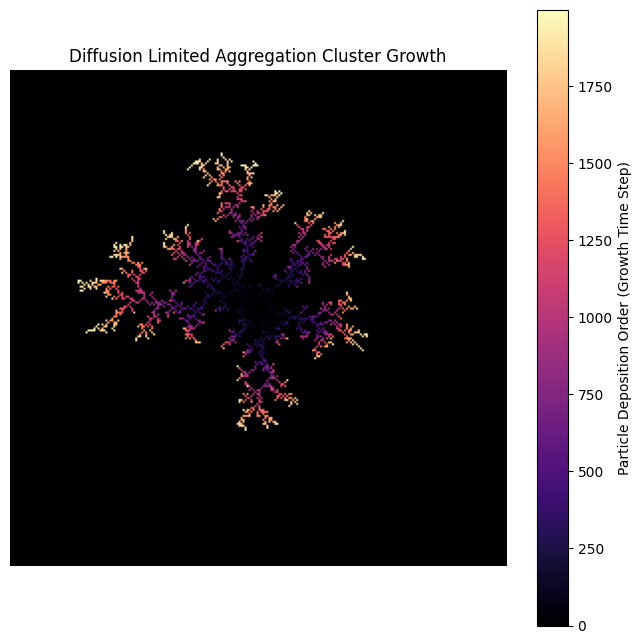

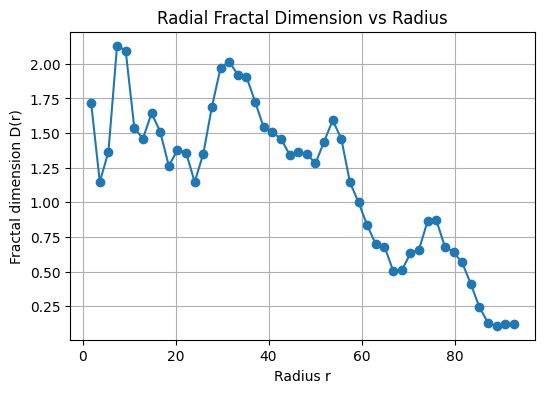

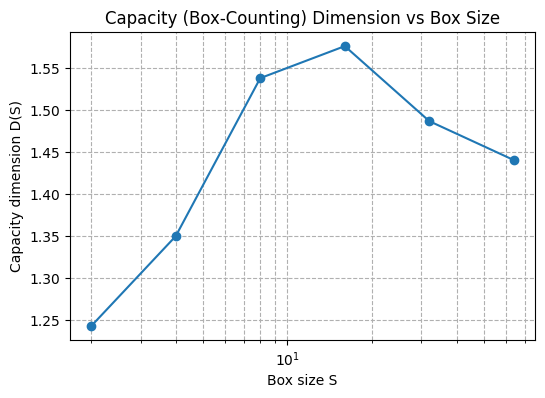

In [28]:
# Simulation parameters
grid_size       = 250
stickiness      = .5
max_particles   = 2000

# Create simulation object, run the simulation, and plot the results
sim = DLA(grid_size, stickiness, max_particles)
sim.simulate()
# sim.plot()
# sim.animate()
# ani = sim.animate(interval=50, batch=100)